In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GridSearchCV, cross_validate
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, roc_auc_score
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
import matplotlib.pyplot as plt

In [ ]:
# Load and preprocess data
print("="*80)
print("ADULT DATASET - MACHINE LEARNING ANALYSIS")
print("="*80)

# Load training data
train_data = pd.read_csv(r'..\data\adult\adultdata.csv', header=None, na_values='?')

# Column names based on adult.names
columns = ['age', 'workclass', 'fnlwgt', 'education', 'education-num',
           'marital-status', 'occupation', 'relationship', 'race', 'sex',
           'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']
train_data.columns = columns

# Load test data (skip first line which is a comment)
test_data = pd.read_csv(r'..\data\adult\adulttest.csv', header=None, skiprows=1, na_values='?')
test_data.columns = columns
# Remove trailing period from income column
test_data['income'] = test_data['income'].str.rstrip('.')

# Combine train and test for preprocessing
data = pd.concat([train_data, test_data], ignore_index=True)

# Separate features and target
X = data.drop('income', axis=1)
y = data['income']

# Identify categorical and numerical columns
categorical_cols = ['workclass', 'education', 'marital-status', 'occupation',
                    'relationship', 'race', 'sex', 'native-country']
numerical_cols = ['age', 'fnlwgt', 'education-num', 'capital-gain',
                  'capital-loss', 'hours-per-week']

# CRITICAL: Strip whitespace from all string columns to fix encoding issues
for col in categorical_cols:
    if col in X.columns:
        X[col] = X[col].astype(str).str.strip()
        # Replace empty strings or '?' with 'Unknown'
        X[col] = X[col].replace(['', '?', 'nan', 'None'], 'Unknown')

# Convert numerical columns to numeric, coercing errors to NaN
for col in numerical_cols:
    if col in X.columns:
        X[col] = pd.to_numeric(X[col], errors='coerce')

# Handle missing values - fill with mode for categorical, median for numerical
for col in categorical_cols:
    if col in X.columns:
        X[col] = X[col].fillna(X[col].mode()[0] if not X[col].mode().empty else 'Unknown')
for col in numerical_cols:
    if col in X.columns:
        X[col] = X[col].fillna(X[col].median())

# Since we're using cross-validation, we use 100% of the data
# No need to split into train/test - CV will handle the splitting internally

# Separate numerical and categorical features
X_numerical = X[numerical_cols].copy()
X_categorical = X[categorical_cols].copy()

# Ensure numerical columns are actually numeric (convert to float)
for col in numerical_cols:
    X_numerical[col] = pd.to_numeric(X_numerical[col], errors='coerce').fillna(X_numerical[col].median())

# Apply one-hot encoding to categorical variables
X_cat_encoded = pd.get_dummies(X_categorical, columns=categorical_cols,
                                     prefix=categorical_cols, drop_first=False)

# Combine numerical and one-hot encoded categorical features
X_combined = pd.concat([X_numerical, X_cat_encoded], axis=1)

# Ensure all columns are numeric before converting to numpy
X_combined = X_combined.astype(float)

# Convert to numpy arrays for sklearn
X_combined = X_combined.values

# Final verification: ensure no NaN or inf values
X_combined = np.nan_to_num(X_combined, nan=0.0, posinf=0.0, neginf=0.0)

# Encode target variable
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_combined)

# X_scaled: Scaled data for models that need it (LR, kNN, SVM, MLP)
# X_combined: Unscaled data for Decision Trees (trees don't need scaling)
# y_encoded: Encoded target variable

print(f"\nDataset Shape: {data.shape}")
print(f"Total samples: {len(X_scaled)}")
print(f"Original features: {len(numerical_cols) + len(categorical_cols)}")
print(f"Features after one-hot encoding: {X_scaled.shape[1]}")
print(f"Target distribution: {np.bincount(y_encoded)}") #income less more than 50k vs less than
print(f"\nNote: Using 100% of data for cross-validation (no train/test split needed).")
print(f"Note: Categorical variables have been one-hot encoded.")

ADULT DATASET - MACHINE LEARNING ANALYSIS

Dataset Shape: (48842, 15)
Total samples: 48842
Original features: 14
Features after one-hot encoding: 108
Target distribution: [37155 11687]

Note: Using 100% of data for cross-validation (no train/test split needed).
Note: Categorical variables have been one-hot encoded.


In [ ]:
# function to plot metrics vs changing hyperparameters

def plot_metrics(df, x, title, log_scale=False):
    plt.figure(figsize=(8,5))

    # Always convert x column to string to handle mixed types (e.g., gamma)
    x_vals = df[x].astype(str)

    plt.plot(x_vals, df["Mean Accuracy"], marker='o', label="Accuracy")
    plt.plot(x_vals, df["Mean F1"], marker='o', label="F1 Score")
    plt.plot(x_vals, df["Mean AUC"], marker='o', label="AUC RUC")

    # Log scale only applies to true numeric x values
    if log_scale:
        # Only apply log scale if values are numeric
        try:
            numeric_vals = pd.to_numeric(df[x], errors='raise')
            plt.xscale("log")
        except:
            print("⚠ Log scale ignored: X axis contains non-numeric values.")

    plt.title(title)
    plt.xlabel(x)
    plt.ylabel("Metric Value")
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
def evaluate_model(model, X, y, cv):
    """
    Evaluates a model using cross-validation and returns mean and variance of specified metrics.

    Args:
        model: The scikit-learn model to evaluate.
        X (pd.DataFrame or np.array): Features.
        y (pd.Series or np.array): Target variable.
        cv (int): Number of cross-validation folds.

    Returns:
        dict: A dictionary containing mean and variance for accuracy, F1-score, and ROC AUC.
    """
    cv_results = cross_validate(model, X, y, cv=cv, scoring=['accuracy', 'f1', 'roc_auc'])

    mean_accuracy = cv_results['test_accuracy'].mean()
    mean_f1 = cv_results['test_f1'].mean()
    mean_auc = cv_results['test_roc_auc'].mean()

    return {
        'Mean Accuracy': mean_accuracy,
        'Mean F1 Score': mean_f1,
        'Mean AUC': mean_auc,
    }

# Logistic Regression

In [ ]:

# 1. LOGISTIC REGRESSION


print("1. LOGISTIC REGRESSION")


penalties = [None, 'l2', 'l1', 'elasticnet']
solvers = ['liblinear', 'lbfgs', 'saga']
reg_strengths = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
L1_ratios = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]

print("\nPerforming Hyperparameter Evaluation...")


# 1 — Across SOLVERS

results1 = []
for solver in solvers:

    if solver == 'liblinear':
        current_penalty = 'l1'
    else:
        current_penalty = 'l2'

    model = LogisticRegression(
        solver=solver,
        penalty=current_penalty,
        C=1,
        max_iter=2000,
        random_state=42
    )
    cv_results = cross_validate(model, X_scaled, y_encoded, cv=5, scoring=['accuracy', 'f1', 'roc_auc'], n_jobs=-1)

    results1.append({
        'Penalty': model.penalty,
        'Solver': solver,
        'Regularisation Strength': 1.0,
        'L1 Ratio': None,
        'Mean Accuracy': cv_results['test_accuracy'].mean(),
        'Mean F1': cv_results['test_f1'].mean(),
        'Mean AUC': cv_results['test_roc_auc'].mean()
    })


# 2 — Across PENALTIES (YOUR LOGIC: saga only, with constraints)

results2 = []
for penalty in penalties:
    solver_used = '' # To store the actual solver used for printing
    # skip invalid combinations
    if penalty == 'l1':
        solver_used = 'saga'
        model = LogisticRegression(
            penalty='l1',
            solver='saga',
            C=1,
            max_iter=2000,
            random_state=42
        )
    elif penalty == 'elasticnet':
        solver_used = 'saga'
        model = LogisticRegression(
            penalty='elasticnet',
            solver='saga',
            l1_ratio=0.5,
            C=1,
            max_iter=2000,
            random_state=42
        )
    else:  # l2 or None (previously 'none')
        solver_used = 'lbfgs' # lbfgs supports l2 and None
        model = LogisticRegression(
            penalty=penalty,
            solver='lbfgs',
            C=1,
            max_iter=2000,
            random_state=42
        )

    cv_results = cross_validate(model, X_scaled, y_encoded, cv=5, scoring=['accuracy', 'f1', 'roc_auc'], n_jobs=-1)

    results2.append({
        'Penalty': penalty,
        'Solver': solver_used,
        'Regularisation Strength': 1.0,
        'L1 Ratio': 0.5 if penalty == 'elasticnet' else None,
        'Mean Accuracy': cv_results['test_accuracy'].mean(),
        'Mean F1': cv_results['test_f1'].mean(),
        'Mean AUC': cv_results['test_roc_auc'].mean()
    })

# 3 — Across C values (YOUR grid-search reg_strengths)

results3 = []
for C in reg_strengths:
    model = LogisticRegression(
        solver='lbfgs',
        penalty='l2',
        C=C,
        max_iter=2000,
        random_state=42
    )
    cv_results = cross_validate(model, X_scaled, y_encoded, cv=5, scoring=['accuracy', 'f1', 'roc_auc'], n_jobs=-1)

    results3.append({
        'Penalty': 'l2',
        'Solver': 'lbfgs',
        'Regularisation Strength': C,
        'L1 Ratio': None,
        'Mean Accuracy': cv_results['test_accuracy'].mean(),
        'Mean F1': cv_results['test_f1'].mean(),
        'Mean AUC': cv_results['test_roc_auc'].mean()
    })


# 4 — Across L1 RATIOS (elasticnet valid only with saga)

results4 = []
for l1_ratio in L1_ratios:
    model = LogisticRegression(
        penalty='elasticnet',
        solver='saga',
        C=1,
        l1_ratio=l1_ratio,
        max_iter=2000,
        random_state=42
    )
    cv_results = cross_validate(model, X_scaled, y_encoded, cv=5, scoring=['accuracy', 'f1', 'roc_auc'], n_jobs=-1)

    results4.append({
        'Penalty': 'elasticnet',
        'Solver': 'saga',
        'Regularisation Strength': 1.0,
        'L1 Ratio': l1_ratio,
        'Mean Accuracy': cv_results['test_accuracy'].mean(),
        'Mean F1': cv_results['test_f1'].mean(),
        'Mean AUC': cv_results['test_roc_auc'].mean()
    })


# Convert to DataFrames

df_results1 = pd.DataFrame(results1)
df_results2 = pd.DataFrame(results2)
df_results3 = pd.DataFrame(results3)
df_results4 = pd.DataFrame(results4)


# Variances (same as your target code)

hp_solv_acc = df_results1['Mean Accuracy'].var()
hp_solv_f1 = df_results1['Mean F1'].var()
hp_solv_auc = df_results1['Mean AUC'].var()

hp_pnlt_acc = df_results2['Mean Accuracy'].var()
hp_pnlt_f1 = df_results2['Mean F1'].var()
hp_pnlt_auc = df_results2['Mean AUC'].var()

hp_regs_acc = df_results3['Mean Accuracy'].var()
hp_regs_f1 = df_results3['Mean F1'].var()
hp_regs_auc = df_results3['Mean AUC'].var()

hp_l1ra_acc = df_results4['Mean Accuracy'].var()
hp_l1ra_f1 = df_results4['Mean F1'].var()
hp_l1ra_auc = df_results4['Mean AUC'].var()

print("\nVariance Across Hyperparameters:")
print("Solver Variance (Accuracy):", hp_solv_acc)
print("Solver Variance (F1):", hp_solv_f1)
print("Solver Variance (AUC):", hp_solv_auc)
print("Penalty Variance (Accuracy):", hp_pnlt_acc)
print("Penalty Variance (F1):", hp_pnlt_f1)
print("Penalty Variance (AUC):", hp_pnlt_auc)
print("C Variance (Accuracy):", hp_regs_acc)
print("C Variance (F1):", hp_regs_f1)
print("C Variance (AUC):", hp_regs_auc)
print("L1 Ratio Variance (Accuracy):", hp_l1ra_acc)
print("L1 Ratio Variance (F1):", hp_l1ra_f1)
print("L1 Ratio Variance (AUC):", hp_l1ra_auc)

1. LOGISTIC REGRESSION

Performing Hyperparameter Evaluation...

Variance Across Hyperparameters:
Solver Variance (Accuracy): 8.522926840334906e-09
Solver Variance (F1): 4.1603684294918123e-08
Solver Variance (AUC): 5.153433073732455e-10
Penalty Variance (Accuracy): 7.544846195802773e-09
Penalty Variance (F1): 3.431340864390771e-08
Penalty Variance (AUC): 1.9397536872722755e-10
C Variance (Accuracy): 4.986838420531956e-06
C Variance (F1): 0.00011506949670285878
C Variance (AUC): 4.395752878162942e-06
L1 Ratio Variance (Accuracy): 1.1643379616308643e-09
L1 Ratio Variance (F1): 4.264394628824279e-09
L1 Ratio Variance (AUC): 6.531746287381386e-11


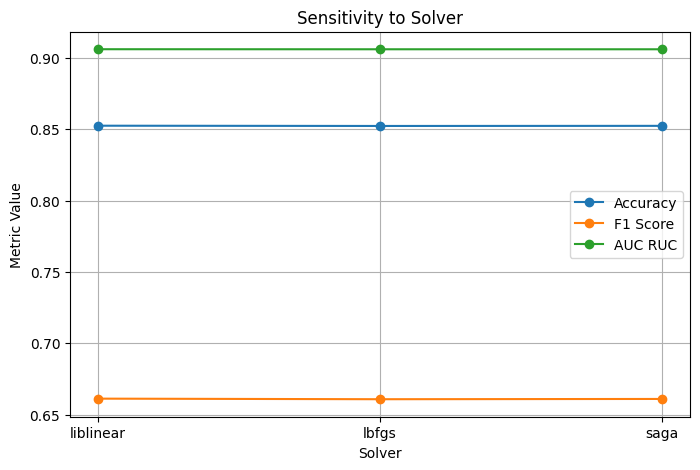

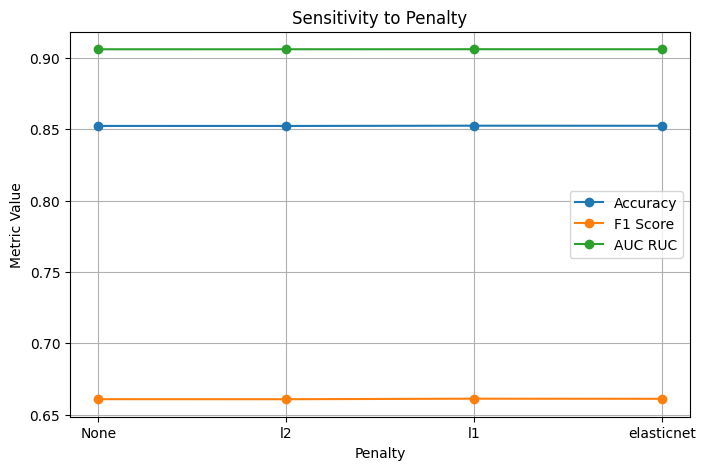

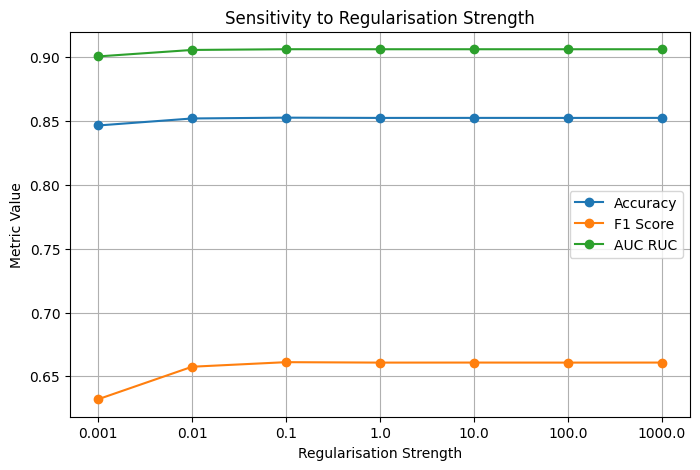

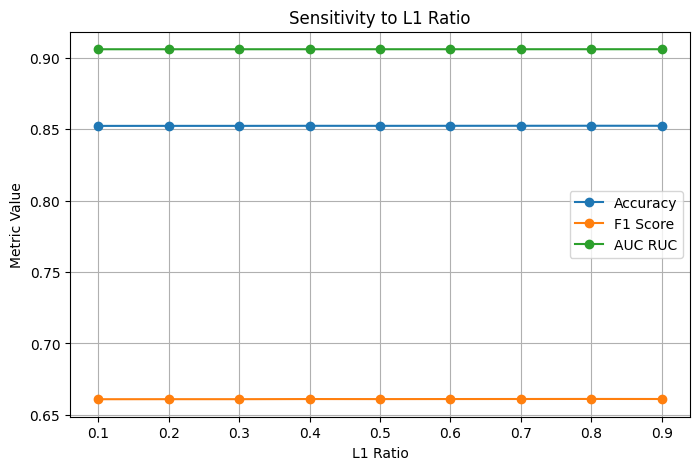

In [ ]:
plot_metrics(df_results1, 'Solver', 'Sensitivity to Solver')
plot_metrics(df_results2, 'Penalty', 'Sensitivity to Penalty')
plot_metrics(df_results3, 'Regularisation Strength', 'Sensitivity to Regularisation Strength')
plot_metrics(df_results4, 'L1 Ratio', 'Sensitivity to L1 Ratio')

# KNN

In [ ]:
# 2. K-NEAREST NEIGHBORS (KNN)
# Function evaluate_model is defined above for KNN
print("2. K-NEAREST NEIGHBORS (KNN)")

# defining all hyperparameter values
n_neighbors_list = [i for i in range(1,32)]
weights_list = ['uniform','distance']
algorithms_list = ['auto', 'ball_tree', 'kd_tree', 'brute']
metric_list = ['euclidean', 'manhattan', 'minkowski','chebyshev','cosine']

print("\nPerforming Hyperparameter Evaluation for KNN...")

# 1  Across N_Neighbors
knn_n_neighbours_results = []
for k in n_neighbors_list:
    model = KNeighborsClassifier(n_neighbors=k, weights='uniform', algorithm='auto', metric='euclidean',n_jobs=-1)
    metrics = evaluate_model(model, X_scaled, y_encoded, cv=5)
    knn_n_neighbours_results.append({
        'N Neighbours': k,
        'Weight Metric': 'uniform',
        'Algorithm': 'auto',
        'Distance Metric': 'euclidean',
        'Mean Accuracy': metrics["Mean Accuracy"],
        'Mean F1': metrics["Mean F1 Score"],
        'Mean AUC': metrics["Mean AUC"]
    })

# 2 Across Weights
knn_weightmetric_results = []
# Using a reasonable default for n_neighbors, e.g., 5
for w in weights_list:
    model = KNeighborsClassifier(n_neighbors=5, weights=w, algorithm='auto', metric='euclidean', n_jobs=-1)
    metrics = evaluate_model(model, X_scaled, y_encoded, cv=5)
    knn_weightmetric_results.append({
        'N Neighbours': 5,
        'Weight Metric': w,
        'Algorithm': 'auto',
        'Distance Metric': 'euclidean',
        'Mean Accuracy': metrics["Mean Accuracy"],
        'Mean F1': metrics["Mean F1 Score"],
        'Mean AUC': metrics["Mean AUC"]
    })

# 3 Across Algorithms
knn_algorithms_results = []
# Using a reasonable default for n_neighbors, e.g., 5
for a in algorithms_list:
    model = KNeighborsClassifier(n_neighbors=5, weights='uniform', algorithm=a, metric='euclidean', n_jobs=-1)
    metrics = evaluate_model(model, X_scaled, y_encoded, cv=5)
    knn_algorithms_results.append({
        'N Neighbours': 5,
        'Weight Metric': 'uniform',
        'Algorithm': a,
        'Distance Metric': 'euclidean',
        'Mean Accuracy': metrics["Mean Accuracy"],
        'Mean F1': metrics["Mean F1 Score"],
        'Mean AUC': metrics["Mean AUC"]
    })

# 4 Across Distance Metrics
knn_distmetric_results = []
# Using a reasonable default for n_neighbors, e.g., 5
for d in metric_list:
    # cosine metric in KNN does not support p (power parameter for Minkowski metric)
    # and some combinations of algorithm and metric might be incompatible.
    # For simplicity, we'll try to use 'auto' algorithm which handles most cases.
    if d == 'cosine':
        model = KNeighborsClassifier(n_neighbors=5, weights='uniform', algorithm='brute', metric=d, n_jobs=-1)
    else:
        model = KNeighborsClassifier(n_neighbors=5, weights='uniform', algorithm='auto', metric=d, n_jobs=-1)
    metrics = evaluate_model(model, X_scaled, y_encoded, cv=5)
    knn_distmetric_results.append({
        'N Neighbours': 5,
        'Weight Metric': 'uniform',
        'Algorithm': 'auto' if d != 'cosine' else 'brute',
        'Distance Metric': d,
        'Mean Accuracy': metrics["Mean Accuracy"],
        'Mean F1': metrics["Mean F1 Score"],
        'Mean AUC': metrics["Mean AUC"]
    })

# Convert to DataFrames
df_knn_n_neighbours = pd.DataFrame(knn_n_neighbours_results)
df_knn_weightmetric = pd.DataFrame(knn_weightmetric_results)
df_knn_algorithms = pd.DataFrame(knn_algorithms_results)
df_knn_distmetric = pd.DataFrame(knn_distmetric_results)



# Calculate and Print Variances

hp_knn_n_acc = df_knn_n_neighbours['Mean Accuracy'].var()
hp_knn_n_f1 = df_knn_n_neighbours['Mean F1'].var()
hp_knn_n_auc = df_knn_n_neighbours['Mean AUC'].var()

hp_knn_w_acc = df_knn_weightmetric['Mean Accuracy'].var()
hp_knn_w_f1 = df_knn_weightmetric['Mean F1'].var()
hp_knn_w_auc = df_knn_weightmetric['Mean AUC'].var()

hp_knn_a_acc = df_knn_algorithms['Mean Accuracy'].var()
hp_knn_a_f1 = df_knn_algorithms['Mean F1'].var()
hp_knn_a_auc = df_knn_algorithms['Mean AUC'].var()

hp_knn_d_acc = df_knn_distmetric['Mean Accuracy'].var()
hp_knn_d_f1 = df_knn_distmetric['Mean F1'].var()
hp_knn_d_auc = df_knn_distmetric['Mean AUC'].var()

print("\nVariance Across KNN Hyperparameters:")
print("N_Neighbors Variance (Accuracy Variance):", hp_knn_n_acc)
print("N_Neighbors Variance (F1 Variance):", hp_knn_n_f1)
print("N_Neighbors Variance (AUC Variance):", hp_knn_n_auc)

print("Weight Metric Variance (Accuracy Variance):", hp_knn_w_acc)
print("Weight Metric Variance (F1 Variance):", hp_knn_w_f1)
print("Weight Metric Variance (AUC Variance):", hp_knn_w_auc)

print("Algorithm Variance (Accuracy Variance):", hp_knn_a_acc)
print("Algorithm Variance (F1 Variance):", hp_knn_a_f1)
print("Algorithm Variance (AUC Variance):", hp_knn_a_auc)

print("Distance Metric Variance (Accuracy Variance):", hp_knn_d_acc)
print("Distance Metric Variance (F1 Variance):", hp_knn_d_f1)
print("Distance Metric Variance (AUC Variance):", hp_knn_d_auc)

2. K-NEAREST NEIGHBORS (KNN)

Performing Hyperparameter Evaluation for KNN...

Variance Across KNN Hyperparameters:
N_Neighbors Variance (Accuracy Variance): 8.140211266333312e-05
N_Neighbors Variance (F1 Variance): 0.0007016202890910347
N_Neighbors Variance (AUC Variance): 0.0012141772468497482
Weight Metric Variance (Accuracy Variance): 1.5735676616740396e-05
Weight Metric Variance (F1 Variance): 4.16593608600819e-05
Weight Metric Variance (AUC Variance): 1.061718539577105e-06
Algorithm Variance (Accuracy Variance): 0.0
Algorithm Variance (F1 Variance): 0.0
Algorithm Variance (AUC Variance): 4.2850730518121153e-11
Distance Metric Variance (Accuracy Variance): 2.151818199006108e-05
Distance Metric Variance (F1 Variance): 0.00010502805661681135
Distance Metric Variance (AUC Variance): 7.667729715297441e-05


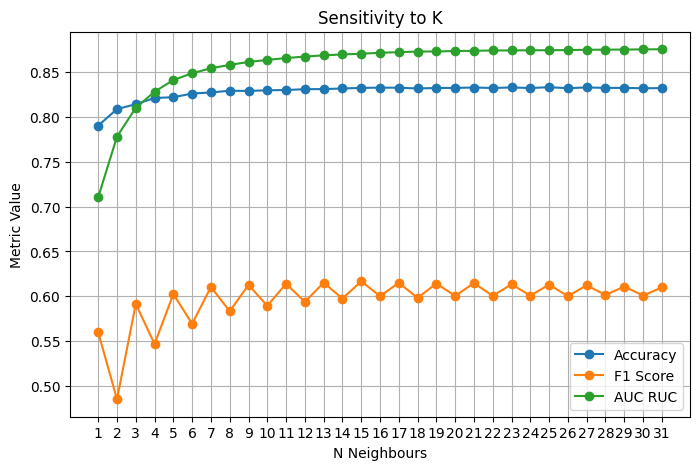

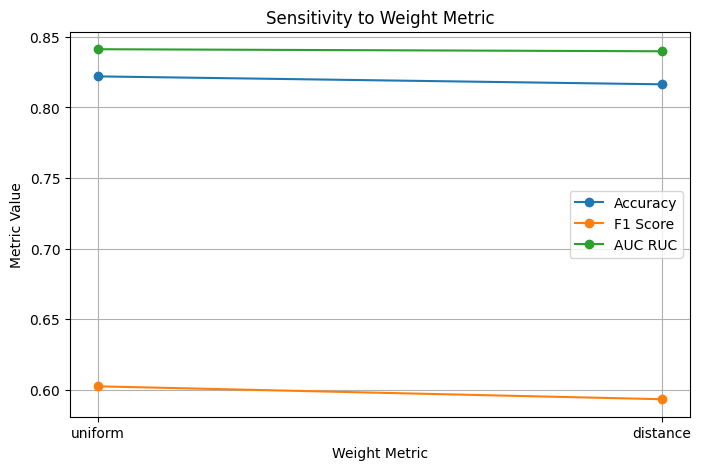

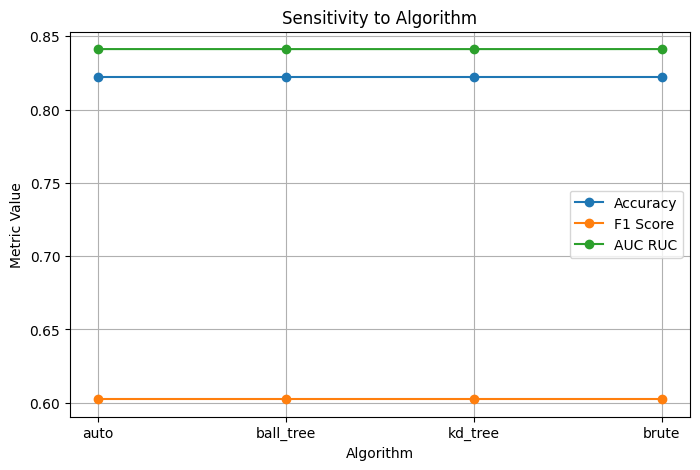

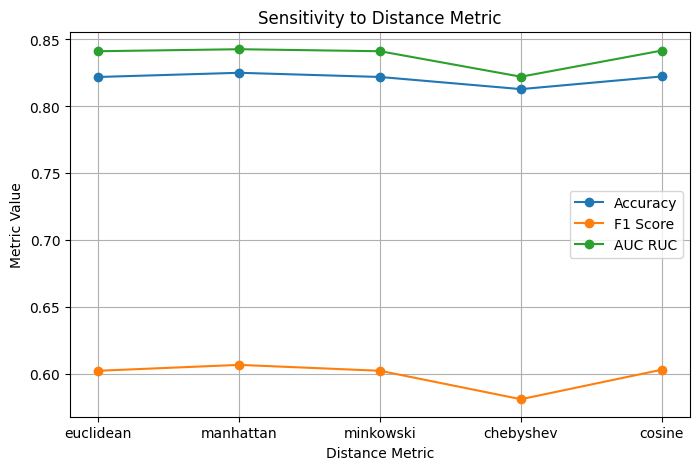

In [ ]:
plot_metrics(df_knn_n_neighbours, "N Neighbours", "Sensitivity to K")
plot_metrics(df_knn_weightmetric, "Weight Metric", "Sensitivity to Weight Metric")
plot_metrics(df_knn_algorithms, "Algorithm", "Sensitivity to Algorithm")
plot_metrics(df_knn_distmetric, "Distance Metric", "Sensitivity to Distance Metric")

# Decision Trees


In [ ]:

# 3. DECISION TREES


print("3. DECISION TREES")


# Hyperparameter values
criteria = ['gini','entropy','log_loss']
max_depths = [None,2,3,5,10,15,20]
min_samples_splits = [2,5,10,15,20]
min_samples_leafs = [1,2,5,8,10]
max_features = [None, 'sqrt', 'log2']

print("\nPerforming Hyperparameter Evaluation for Decision Trees...")


# 1 — Across Criteria

dt_criteria_results = []
for c in criteria:
    try:
        model = DecisionTreeClassifier(criterion=c,
                                       max_depth=None, # Default
                                       min_samples_split=2, # Default
                                       min_samples_leaf=1, # Default
                                       max_features=None, # Default
                                       random_state=42)
        metrics = evaluate_model(model, X_scaled, y_encoded, cv=10)
        dt_criteria_results.append({
            'Criterion': c,
            'Max Depth': None,
            'Min Samples Split': 2,
            'Min Samples Leaf': 1,
            'Max Features' : None,
            'Mean Accuracy': metrics["Mean Accuracy"],
            'Mean F1': metrics["Mean F1 Score"],
            'Mean AUC': metrics["Mean AUC"]
        })
    except ValueError as e:
        print(f"Skipping criterion '{c}' due to error: {e}")
        dt_criteria_results.append({
            'Criterion': c,
            'Max Depth': None,
            'Min Samples Split': 2,
            'Min Samples Leaf': 1,
            'Max Features' : None,
            'Mean Accuracy': np.nan,
            'Mean F1': np.nan,
            'Mean AUC': np.nan
        })

# 2 — Across Max Depths

dt_maxdepth_results = []
for d in max_depths:
    model = DecisionTreeClassifier(criterion='entropy', # Default
                                   max_depth=d,
                                   min_samples_split=2, # Default
                                   min_samples_leaf=1, # Default
                                   max_features=None, # Default
                                   random_state=42)
    metrics = evaluate_model(model, X_scaled, y_encoded, cv=10)
    dt_maxdepth_results.append({
        'Criterion': 'entropy',
        'Max Depth': d,
        'Min Samples Split': 2,
        'Min Samples Leaf': 1,
        'Max Features' : None,
        'Mean Accuracy': metrics["Mean Accuracy"],
        'Mean F1': metrics["Mean F1 Score"],
        'Mean AUC': metrics["Mean AUC"]
    })

# 3 — Across Min Samples Splits

dt_minsamplesplit_results = []
for s in min_samples_splits:
    model = DecisionTreeClassifier(criterion='entropy', # Default
                                   max_depth=None, # Default
                                   min_samples_split=s,
                                   min_samples_leaf=1, # Default
                                   max_features=None, # Default
                                   random_state=42)
    metrics = evaluate_model(model, X_scaled, y_encoded, cv=10)
    dt_minsamplesplit_results.append({
        'Criterion': 'entropy',
        'Max Depth': None,
        'Min Samples Split': s,
        'Min Samples Leaf': 1,
        'Max Features' : None,
        'Mean Accuracy': metrics["Mean Accuracy"],
        'Mean F1': metrics["Mean F1 Score"],
        'Mean AUC': metrics["Mean AUC"]
    })


# 4 — Across Min Samples Leafs

dt_minsamplesleaf_results = []
for l in min_samples_leafs:
    model = DecisionTreeClassifier(criterion='entropy', # Default
                                   max_depth=None, # Default
                                   min_samples_split=2, # Default
                                   min_samples_leaf=l,
                                   max_features=None, # Default
                                   random_state=42)
    metrics = evaluate_model(model, X_scaled, y_encoded, cv=10)
    dt_minsamplesleaf_results.append({
        'Criterion': 'entropy',
        'Max Depth': None,
        'Min Samples Split': 2,
        'Min Samples Leaf': l,
        'Max Features' : None,
        'Mean Accuracy': metrics["Mean Accuracy"],
        'Mean F1': metrics["Mean F1 Score"],
        'Mean AUC': metrics["Mean AUC"]
    })


# 5 — Across Max Features

dt_maxfeatures_results = []
for f in max_features:
    model = DecisionTreeClassifier(criterion='entropy', # Default
                                   max_depth=None, # Default
                                   min_samples_split=2, # Default
                                   min_samples_leaf=1, # Default
                                   max_features=f,
                                   random_state=42)
    metrics = evaluate_model(model, X_scaled, y_encoded, cv=10)
    dt_maxfeatures_results.append({
        'Criterion': 'entropy',
        'Max Depth': None,
        'Min Samples Split': 2,
        'Min Samples Leaf': 1,
        'Max Features' : f,
        'Mean Accuracy': metrics["Mean Accuracy"],
        'Mean F1': metrics["Mean F1 Score"],
        'Mean AUC': metrics["Mean AUC"]
    })


# Convert to DataFrames

df_dt_criteria = pd.DataFrame(dt_criteria_results)
df_dt_maxdepth = pd.DataFrame(dt_maxdepth_results)
df_dt_minsamplesplit = pd.DataFrame(dt_minsamplesplit_results)
df_dt_minsamplesleaf = pd.DataFrame(dt_minsamplesleaf_results)
df_dt_maxfeatures = pd.DataFrame(dt_maxfeatures_results)


# Calculate and Print Variances

# Calculate variances of the MEAN metrics for each hyperparameter
hp_dt_crit_acc = df_dt_criteria['Mean Accuracy'].var()
hp_dt_crit_f1 = df_dt_criteria['Mean F1'].var()
hp_dt_crit_auc = df_dt_criteria['Mean AUC'].var()

hp_dt_maxd_acc = df_dt_maxdepth['Mean Accuracy'].var()
hp_dt_maxd_f1 = df_dt_maxdepth['Mean F1'].var()
hp_dt_maxd_auc = df_dt_maxdepth['Mean AUC'].var()

hp_dt_split_acc = df_dt_minsamplesplit['Mean Accuracy'].var()
hp_dt_split_f1 = df_dt_minsamplesplit['Mean F1'].var()
hp_dt_split_auc = df_dt_minsamplesplit['Mean AUC'].var()

hp_dt_leaf_acc = df_dt_minsamplesleaf['Mean Accuracy'].var()
hp_dt_leaf_f1 = df_dt_minsamplesleaf['Mean F1'].var()
hp_dt_leaf_auc = df_dt_minsamplesleaf['Mean AUC'].var()

hp_dt_maxf_acc = df_dt_maxfeatures['Mean Accuracy'].var()
hp_dt_maxf_f1 = df_dt_maxfeatures['Mean F1'].var()
hp_dt_maxf_auc = df_dt_maxfeatures['Mean AUC'].var()


print("\nVariance Across Decision Tree Hyperparameters:")
print("Criteria Variance (Mean Accuracy):", hp_dt_crit_acc)
print("Criteria Variance (Mean F1):", hp_dt_crit_f1)
print("Criteria Variance (Mean AUC):", hp_dt_crit_auc)

print("Max Depth Variance (Mean Accuracy):", hp_dt_maxd_acc)
print("Max Depth Variance (Mean F1):", hp_dt_maxd_f1)
print("Max Depth Variance (Mean AUC):", hp_dt_maxd_auc)

print("Min Samples Split Variance (Mean Accuracy):", hp_dt_split_acc)
print("Min Samples Split Variance (Mean F1):", hp_dt_split_f1)
print("Min Samples Split Variance (Mean AUC):", hp_dt_split_auc)

print("Min Samples Leaf Variance (Mean Accuracy):", hp_dt_leaf_acc)
print("Min Samples Leaf Variance (Mean F1):", hp_dt_leaf_f1)
print("Min Samples Leaf Variance (Mean AUC):", hp_dt_leaf_auc)

print("Max Features Variance (Mean Accuracy):", hp_dt_maxf_acc)
print("Max Features Variance (Mean F1):", hp_dt_maxf_f1)
print("Max Features Variance (Mean AUC):", hp_dt_maxf_auc)

3. DECISION TREES

Performing Hyperparameter Evaluation for Decision Trees...

Variance Across Decision Tree Hyperparameters:
Criteria Variance (Mean Accuracy): 2.0453903364440892e-06
Criteria Variance (Mean F1): 8.954027439986487e-06
Criteria Variance (Mean AUC): 4.0731110379059036e-06
Max Depth Variance (Mean Accuracy): 0.00023184304458564336
Max Depth Variance (Mean F1): 0.003050368955677471
Max Depth Variance (Mean AUC): 0.0024872136875617712
Min Samples Split Variance (Mean Accuracy): 4.0084610934116763e-05
Min Samples Split Variance (Mean F1): 5.6336874362853216e-05
Min Samples Split Variance (Mean AUC): 0.0011880413589268489
Min Samples Leaf Variance (Mean Accuracy): 0.00012622435044859563
Min Samples Leaf Variance (Mean F1): 0.00020088239188123552
Min Samples Leaf Variance (Mean AUC): 0.0028468345313683056
Max Features Variance (Mean Accuracy): 2.3119590891617184e-05
Max Features Variance (Mean F1): 0.00014864355419832908
Max Features Variance (Mean AUC): 7.377090473987784e-05


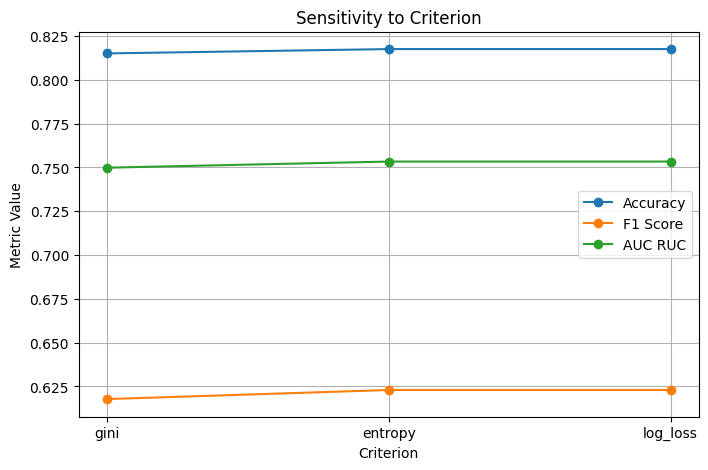

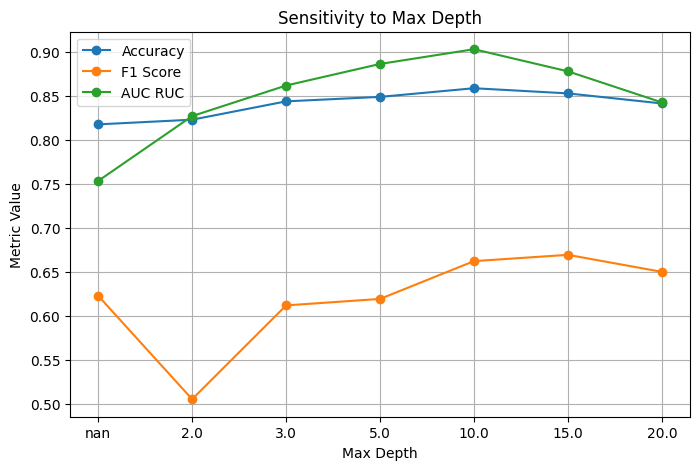

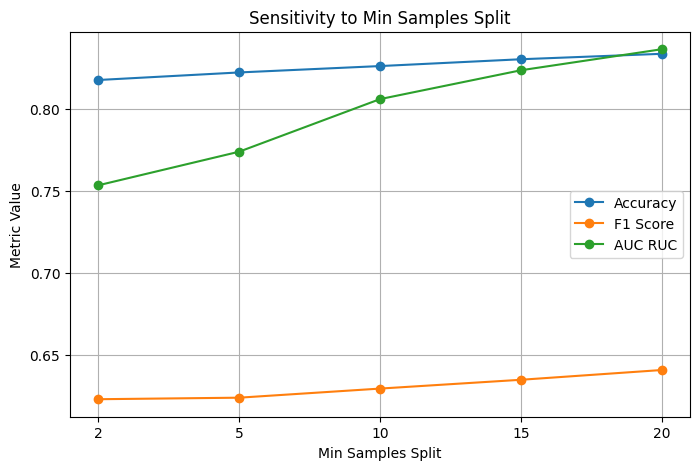

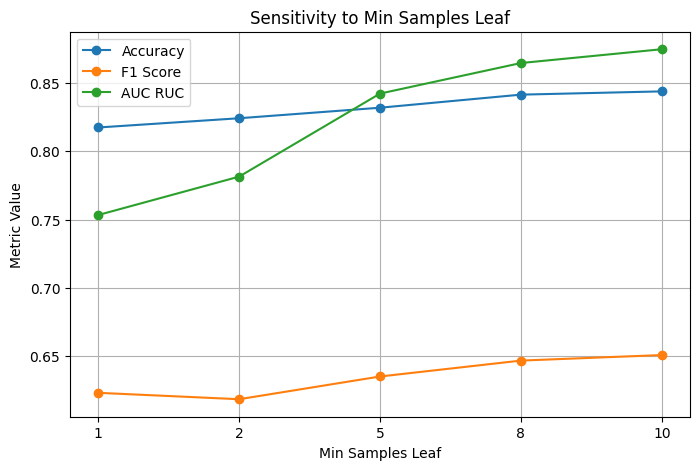

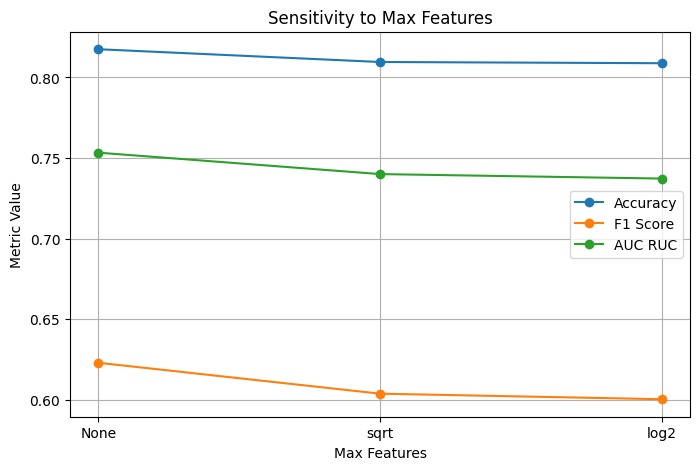

In [ ]:
plot_metrics(df_dt_criteria, "Criterion", "Sensitivity to Criterion")
plot_metrics(df_dt_maxdepth, "Max Depth", "Sensitivity to Max Depth")
plot_metrics(df_dt_minsamplesplit, "Min Samples Split", "Sensitivity to Min Samples Split")
plot_metrics(df_dt_minsamplesleaf, "Min Samples Leaf", "Sensitivity to Min Samples Leaf")
plot_metrics(df_dt_maxfeatures, "Max Features", "Sensitivity to Max Features")

# SVM

In [ ]:
#SVM
# HYPERPARAMETER GRIDS
C_vals = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
degrees = [2, 3, 4, 5]
gammas = ['scale', 'auto', 0.001, 0.01, 0.1, 1]

# STORAGE LISTS
results_C = []
results_kernel = []
results_degree = []
results_gamma = []

1


In [ ]:
# KERNEL
model = SVC(kernel='linear',
            degree=3,
            gamma='scale',
            probability=True)

cv_results = cross_validate(model, X_scaled, y_encoded, cv=3, scoring=['accuracy', 'f1', 'roc_auc'], n_jobs=-1)

results_kernel.append({
    'C': 1.0, 'Kernel': 'linear',
    'Degree': 3,
    'Gamma': 'scale',
    'Mean Accuracy': cv_results['test_accuracy'].mean(),
    'Mean F1': cv_results['test_f1'].mean(),
    'Mean AUC': cv_results['test_roc_auc'].mean()
})

df_kernel = pd.DataFrame(results_kernel)
display(df_kernel)

,C,Kernel,Degree,Gamma,Mean Accuracy,Mean F1,Mean AUC
0,1.0,linear,3,scale,0.851153,0.650913,0.902466


In [ ]:
model = SVC(kernel='poly',
            degree=3,
            gamma='scale',
            probability=True)

cv_results = cross_validate(model, X_scaled, y_encoded, cv=3, scoring=['accuracy', 'f1', 'roc_auc'], n_jobs=-1)

results_kernel.append({
    'C': 1.0, 'Kernel': 'poly',
    'Degree': 3,
    'Gamma': 'scale',
    'Mean Accuracy': cv_results['test_accuracy'].mean(),
    'Mean F1': cv_results['test_f1'].mean(),
    'Mean AUC': cv_results['test_roc_auc'].mean()
})

df_kernel = pd.DataFrame(results_kernel)
display(df_kernel)

,C,Kernel,Degree,Gamma,Mean Accuracy,Mean F1,Mean AUC
0,1.0,linear,3,scale,0.851153,0.650913,0.902466
1,1.0,poly,3,scale,0.833197,0.585365,0.870698


In [ ]:
model = SVC(kernel='rbf',
            degree=3,
            gamma='scale',
            probability=True)

cv_results = cross_validate(model, X_scaled, y_encoded, cv=3, scoring=['accuracy', 'f1', 'roc_auc'], n_jobs=-1)

results_kernel.append({
    'C': 1.0, 'Kernel': 'rbf',
    'Degree': 3,
    'Gamma': 'scale',
    'Mean Accuracy': cv_results['test_accuracy'].mean(),
    'Mean F1': cv_results['test_f1'].mean(),
    'Mean AUC': cv_results['test_roc_auc'].mean()
})

df_kernel = pd.DataFrame(results_kernel)
display(df_kernel)

,C,Kernel,Degree,Gamma,Mean Accuracy,Mean F1,Mean AUC
0,1.0,linear,3,scale,0.851153,0.650913,0.902466
1,1.0,poly,3,scale,0.833197,0.585365,0.870698
2,1.0,rbf,3,scale,0.849351,0.642850,0.892227


In [ ]:
model = SVC(kernel='sigmoid',
            degree=3,
            gamma='scale',
            probability=True)

cv_results = cross_validate(model, X_scaled, y_encoded, cv=3, scoring=['accuracy', 'f1', 'roc_auc'], n_jobs=-1)

results_kernel.append({
    'C': 1.0, 'Kernel': 'sigmoid',
    'Degree': 3,
    'Gamma': 'scale',
    'Mean Accuracy': cv_results['test_accuracy'].mean(),
    'Mean F1': cv_results['test_f1'].mean(),
    'Mean AUC': cv_results['test_roc_auc'].mean()
})

df_kernel = pd.DataFrame(results_kernel)
display(df_kernel)

,C,Kernel,Degree,Gamma,Mean Accuracy,Mean F1,Mean AUC
0,1.0,linear,3,scale,0.851153,0.650913,0.902466
1,1.0,poly,3,scale,0.833197,0.585365,0.870698
2,1.0,rbf,3,scale,0.849351,0.642850,0.892227
3,1.0,sigmoid,3,scale,0.824086,0.609586,0.856569


In [ ]:
svm_hp_kern_acc = (df_kernel['Mean Accuracy'].var())
svm_hp_kern_f1 = (df_kernel['Mean F1'].var())
svm_hp_kern_auc = (df_kernel['Mean AUC'].var())

print("Variance Across SVM Hyperparameters:")
print("Kernel Variance (Accuracy):", svm_hp_kern_acc)
print("Kernel Variance (F1):", svm_hp_kern_f1)
print("Kernel Variance (AUC):", svm_hp_kern_auc)

Variance Across SVM Hyperparameters:
Kernel Variance (Accuracy): 0.00017004769298986224
Kernel Variance (F1): 0.0009222520001775219
Kernel Variance (AUC): 0.0004295924211783135


In [ ]:
# DEGREE FOR POLY
model = SVC(kernel='poly', degree=2, gamma='scale', probability=True)

cv_results = cross_validate(model, X_scaled, y_encoded, cv=3, scoring=['accuracy', 'f1', 'roc_auc'],n_jobs=-1)

results_degree.append({
    'C': 1.0, 'Kernel': 'poly',
    'Degree': 2, 'Gamma': 'scale',
    'Mean Accuracy': cv_results['test_accuracy'].mean(),
    'Mean F1': cv_results['test_f1'].mean(),
    'Mean AUC': cv_results['test_roc_auc'].mean()
})

df_degree = pd.DataFrame(results_degree)
display(df_degree)

,C,Kernel,Degree,Gamma,Mean Accuracy,Mean F1,Mean AUC
0,1.0,poly,2,scale,0.835818,0.590672,0.860782


In [ ]:
model = SVC(kernel='poly', degree=3, gamma='scale', probability=True)

cv_results = cross_validate(model, X_scaled, y_encoded, cv=3, scoring=['accuracy', 'f1', 'roc_auc'],n_jobs=-1)

results_degree.append({
    'C': 1.0, 'Kernel': 'poly',
    'Degree': 3, 'Gamma': 'scale',
    'Mean Accuracy': cv_results['test_accuracy'].mean(),
    'Mean F1': cv_results['test_f1'].mean(),
    'Mean AUC': cv_results['test_roc_auc'].mean()
})

df_degree = pd.DataFrame(results_degree)
display(df_degree)

,C,Kernel,Degree,Gamma,Mean Accuracy,Mean F1,Mean AUC
0,1.0,poly,2,scale,0.835818,0.590672,0.860782
1,1.0,poly,3,scale,0.833197,0.585365,0.870698


In [ ]:
model = SVC(kernel='poly', degree=4, gamma='scale', probability=True)

cv_results = cross_validate(model, X_scaled, y_encoded, cv=3, scoring=['accuracy', 'f1', 'roc_auc'],n_jobs=-1)

results_degree.append({
    'C': 1.0, 'Kernel': 'poly',
    'Degree': 4, 'Gamma': 'scale',
    'Mean Accuracy': cv_results['test_accuracy'].mean(),
    'Mean F1': cv_results['test_f1'].mean(),
    'Mean AUC': cv_results['test_roc_auc'].mean()
})

df_degree = pd.DataFrame(results_degree)
display(df_degree)

,C,Kernel,Degree,Gamma,Mean Accuracy,Mean F1,Mean AUC
0,1.0,poly,2,scale,0.835818,0.590672,0.860782
1,1.0,poly,3,scale,0.833197,0.585365,0.870698
2,1.0,poly,4,scale,0.811678,0.465991,0.847466


In [ ]:
model = SVC(kernel='poly', degree=5, gamma='scale', probability=True)

cv_results = cross_validate(model, X_scaled, y_encoded, cv=3, scoring=['accuracy', 'f1', 'roc_auc'],n_jobs=-1)

results_degree.append({
    'C': 1.0, 'Kernel': 'poly',
    'Degree': 5, 'Gamma': 'scale',
    'Mean Accuracy': cv_results['test_accuracy'].mean(),
    'Mean F1': cv_results['test_f1'].mean(),
    'Mean AUC': cv_results['test_roc_auc'].mean()
})

df_degree = pd.DataFrame(results_degree)
display(df_degree)

,C,Kernel,Degree,Gamma,Mean Accuracy,Mean F1,Mean AUC
0,1.0,poly,5,scale,0.797326,0.369619,0.83697


In [ ]:
new_degree_data = [
    {'C': 1.0, 'Kernel': 'poly', 'Degree': 2, 'Gamma': 'scale', 'Mean Accuracy': 0.835818, 'Mean F1': 0.590672, 'Mean AUC': 0.860782},
    {'C': 1.0, 'Kernel': 'poly', 'Degree': 3, 'Gamma': 'scale', 'Mean Accuracy': 0.833197, 'Mean F1': 0.585365, 'Mean AUC': 0.870698},
    {'C': 1.0, 'Kernel': 'poly', 'Degree': 4, 'Gamma': 'scale', 'Mean Accuracy': 0.811678, 'Mean F1': 0.465991, 'Mean AUC': 0.847466}
]

df_degree_to_add = pd.DataFrame(new_degree_data)
df_degree = pd.concat([df_degree, df_degree_to_add], ignore_index=True)

print("Updated df_degree:")
display(df_degree)

Updated df_degree:


,C,Kernel,Degree,Gamma,Mean Accuracy,Mean F1,Mean AUC
0,1.0,poly,5,scale,0.797326,0.369619,0.836970
1,1.0,poly,2,scale,0.835818,0.590672,0.860782
2,1.0,poly,3,scale,0.833197,0.585365,0.870698
3,1.0,poly,4,scale,0.811678,0.465991,0.847466


In [ ]:
svm_hp_degr_acc = (df_degree['Mean Accuracy'].var())
svm_hp_degr_f1 = (df_degree['Mean F1'].var())
svm_hp_degr_auc = (df_degree['Mean AUC'].var())

print("Variance Across SVM Hyperparameters:")
print("Degree Variance (Accuracy):", svm_hp_degr_acc)
print("Degree Variance (F1):", svm_hp_degr_f1)
print("Degree Variance (AUC):", svm_hp_degr_auc)

Variance Across SVM Hyperparameters:
Degree Variance (Accuracy): 0.00033558399256058583
Degree Variance (F1): 0.011210154053070255
Degree Variance (AUC): 0.0002191810419367963


In [ ]:
# GAMMA
model = SVC(kernel='rbf', gamma='scale', probability=True)

cv_results = cross_validate(model, X_scaled, y_encoded, cv=5, scoring=['accuracy', 'f1', 'roc_auc'],n_jobs=-1)

results_gamma.append({
    'C': 1.0, 'Kernel': 'rbf',
    'Degree': None, 'Gamma': 'scale',
    'Mean Accuracy': cv_results['test_accuracy'].mean(),
    'Mean F1': cv_results['test_f1'].mean(),
    'Mean AUC': cv_results['test_roc_auc'].mean()
})

df_gamma = pd.DataFrame(results_gamma)
display(df_gamma)

In [ ]:
display(df_gamma)

,C,Kernel,Degree,Gamma,Mean Accuracy,Mean F1,Mean AUC
0,1.0,rbf,None,scale,0.850129,0.645794,0.892709


In [ ]:
model = SVC(kernel='rbf', gamma='auto', probability=True)

cv_results = cross_validate(model, X_scaled, y_encoded, cv=5, scoring=['accuracy', 'f1', 'roc_auc'],n_jobs=-1)

results_gamma.append({
    'C': 1.0, 'Kernel': 'rbf',
    'Degree': None, 'Gamma': 'auto',
    'Mean Accuracy': cv_results['test_accuracy'].mean(),
    'Mean F1': cv_results['test_f1'].mean(),
    'Mean AUC': cv_results['test_roc_auc'].mean()
})

df_gamma = pd.DataFrame(results_gamma)
display(df_gamma)

,C,Kernel,Degree,Gamma,Mean Accuracy,Mean F1,Mean AUC
0,1.0,rbf,None,scale,0.850129,0.645794,0.892709
1,1.0,rbf,None,auto,0.850211,0.646059,0.892708


In [ ]:
model = SVC(kernel='rbf', gamma=0.01, probability=True)

cv_results = cross_validate(model, X_scaled, y_encoded, cv=5, scoring=['accuracy', 'f1', 'roc_auc'],n_jobs=-1)

results_gamma.append({
    'C': 1.0, 'Kernel': 'rbf',
    'Degree': None, 'Gamma': 0.01,
    'Mean Accuracy': cv_results['test_accuracy'].mean(),
    'Mean F1': cv_results['test_f1'].mean(),
    'Mean AUC': cv_results['test_roc_auc'].mean()
})

df_gamma = pd.DataFrame(results_gamma)
display(df_gamma)

,C,Kernel,Degree,Gamma,Mean Accuracy,Mean F1,Mean AUC
0,1.0,rbf,None,scale,0.850129,0.645794,0.892709
1,1.0,rbf,None,auto,0.850211,0.646059,0.892708
2,1.0,rbf,None,0.01,0.849863,0.645491,0.892005


In [ ]:
model = SVC(kernel='rbf', gamma=0.001, probability=True)

cv_results = cross_validate(model, X_scaled, y_encoded, cv=5, scoring=['accuracy', 'f1', 'roc_auc'],n_jobs=-1)

results_gamma.append({
    'C': 1.0, 'Kernel': 'rbf',
    'Degree': None, 'Gamma': 0.001,
    'Mean Accuracy': cv_results['test_accuracy'].mean(),
    'Mean F1': cv_results['test_f1'].mean(),
    'Mean AUC': cv_results['test_roc_auc'].mean()
})

df_gamma = pd.DataFrame(results_gamma)
display(df_gamma)

,C,Kernel,Degree,Gamma,Mean Accuracy,Mean F1,Mean AUC
0,1.0,rbf,None,0.100,0.849494,0.638048,0.90116
1,1.0,rbf,None,0.001,0.849494,0.638048,0.90116


In [ ]:
model = SVC(kernel='rbf', gamma=0.1, probability=True)

cv_results = cross_validate(model, X_scaled, y_encoded, cv=5, scoring=['accuracy', 'f1', 'roc_auc'],n_jobs=-1)

results_gamma.append({
    'C': 1.0, 'Kernel': 'rbf',
    'Degree': None, 'Gamma': 0.1,
    'Mean Accuracy': cv_results['test_accuracy'].mean(),
    'Mean F1': cv_results['test_f1'].mean(),
    'Mean AUC': cv_results['test_roc_auc'].mean()
})

df_gamma = pd.DataFrame(results_gamma)
display(df_gamma)

In [ ]:
model = SVC(kernel='rbf', gamma=1, probability=True)

cv_results = cross_validate(model, X_scaled, y_encoded, cv=5, scoring=['accuracy', 'f1', 'roc_auc'],n_jobs=-1)

results_gamma.append({
    'C': 1.0, 'Kernel': 'rbf',
    'Degree': None, 'Gamma': 1,
    'Mean Accuracy': cv_results['test_accuracy'].mean(),
    'Mean F1': cv_results['test_f1'].mean(),
    'Mean AUC': cv_results['test_roc_auc'].mean()
})

df_gamma = pd.DataFrame(results_gamma)
display(df_gamma)

In [ ]:
new_gamma_data = [
    {'C': 1.0, 'Kernel': 'rbf', 'Degree': None, 'Gamma': 'scale', 'Mean Accuracy': 0.850129, 'Mean F1': 0.645794, 'Mean AUC': 0.892709},
    {'C': 1.0, 'Kernel': 'rbf', 'Degree': None, 'Gamma': 'auto', 'Mean Accuracy': 0.850211, 'Mean F1': 0.646059, 'Mean AUC': 0.892708},
    {'C': 1.0, 'Kernel': 'rbf', 'Degree': None, 'Gamma': 0.01, 'Mean Accuracy': 0.849863, 'Mean F1': 0.645491, 'Mean AUC': 0.892005},
    {'C': 1.0, 'Kernel': 'rbf', 'Degree': None, 'Gamma': 0.001, 'Mean Accuracy': 0.849494, 'Mean F1': 0.638048, 'Mean AUC': 0.90116}
]

df_gamma = pd.DataFrame(new_gamma_data)

display(df_gamma)

,C,Kernel,Degree,Gamma,Mean Accuracy,Mean F1,Mean AUC
0,1.0,rbf,None,scale,0.850129,0.645794,0.892709
1,1.0,rbf,None,auto,0.850211,0.646059,0.892708
2,1.0,rbf,None,0.01,0.849863,0.645491,0.892005
3,1.0,rbf,None,0.001,0.849494,0.638048,0.901160


In [ ]:
svm_hp_gamm_acc = (df_gamma['Mean Accuracy'].var())
svm_hp_gamm_f1 = (df_gamma['Mean F1'].var())
svm_hp_gamm_auc = (df_gamma['Mean AUC'].var())

print("Variance Across SVM Hyperparameters:")
print("Gamma Variance (Accuracy):", svm_hp_gamm_acc)
print("Gamma Variance (F1):", svm_hp_gamm_f1)
print("Gamma Variance (AUC):", svm_hp_gamm_auc)

Variance Across SVM Hyperparameters:
Gamma Variance (Accuracy): 1.0433825000001957e-07
Gamma Variance (F1): 1.5004962000000285e-05
Gamma Variance (AUC): 1.8971629666666513e-05


In [ ]:
model = SVC(C=0.001, kernel='linear', gamma='scale', probability=True)

cv_results = cross_validate(model, X_scaled, y_encoded, cv=5, scoring=['accuracy', 'f1', 'roc_auc'], n_jobs=-1)

results_C.append({
    'C': 0.001, 'Kernel': 'linear', 'Degree': None, 'Gamma': 'scale',
    'Mean Accuracy': cv_results['test_accuracy'].mean(),
    'Mean F1': cv_results['test_f1'].mean(),
    'Mean AUC': cv_results['test_roc_auc'].mean()
})


df_C = pd.DataFrame(results_C)
display(df_C)

In [ ]:
model = SVC(C=0.01, kernel='linear', gamma='scale', probability=True)

cv_results = cross_validate(model, X_scaled, y_encoded, cv=5, scoring=['accuracy', 'f1', 'roc_auc'], n_jobs=-1)

results_C.append({
    'C': 0.01, 'Kernel': 'linear', 'Degree': None, 'Gamma': 'scale',
    'Mean Accuracy': cv_results['test_accuracy'].mean(),
    'Mean F1': cv_results['test_f1'].mean(),
    'Mean AUC': cv_results['test_roc_auc'].mean()
})


df_C = pd.DataFrame(results_C)
display(df_C)

,C,Kernel,Degree,Gamma,Mean Accuracy,Mean F1,Mean AUC
0,0.01,linear,None,scale,0.851276,0.650089,0.902466


In [ ]:
model = SVC(C=0.1, kernel='linear', gamma='scale', probability=True)

cv_results = cross_validate(model, X_scaled, y_encoded, cv=5, scoring=['accuracy', 'f1', 'roc_auc'], n_jobs=-1)

results_C.append({
    'C': 0.1, 'Kernel': 'linear', 'Degree': None, 'Gamma': 'scale',
    'Mean Accuracy': cv_results['test_accuracy'].mean(),
    'Mean F1': cv_results['test_f1'].mean(),
    'Mean AUC': cv_results['test_roc_auc'].mean()
})


df_C = pd.DataFrame(results_C)
display(df_C)

In [ ]:
plot_metrics(df_C, "C", "Sensitivity to C")
plot_metrics(df_kernel, "Kernel", "Sensitivity to Kernel")
plot_metrics(df_degree, "Degree", "Sensitivity to Degree for Polynomial Kernel")
plot_metrics(df_gamma, "Gamma", "Sensitivity to Gamma")

# MLP


In [ ]:
# MLP
print("5. MULTI-LAYER PERCEPTRON (MLP)")

# -----------------------------
# Hyperparameters to test
# -----------------------------
hidden_layers = [(10,), (50,), (100,), (10, 10), (50, 50), (100, 50)]
activations = ['identity', 'logistic', 'tanh', 'relu']
alphas = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]
learning_rates = ['constant', 'invscaling', 'adaptive']
learning_rate_inits = [0.0001, 0.001, 0.01, 0.1]

# --------------------------------------------
# STORAGE
# --------------------------------------------
results_hidden = []
results_activation = []
results_alpha = []
results_lr = []
results_lr_init = []


# ========================================================
# 1. HIDDEN LAYER SIZES
# ========================================================
for h in hidden_layers:
    model = MLPClassifier(
        hidden_layer_sizes=h,
        activation='relu',
        alpha=0.0001,
        learning_rate='constant',
        max_iter=3000,
        random_state=42
    )

    cv = cross_validate(model, X_scaled, y_encoded, cv=5, scoring=['accuracy', 'f1', 'roc_auc'], n_jobs=-1)

    results_hidden.append({
        'Value': h,
        'Mean Accuracy': cv['test_accuracy'].mean(),
        'Mean AUC': cv['test_roc_auc'].mean(),
        'Mean F1': cv['test_f1'].mean()
    })


# ========================================================
# 2. ACTIVATION
# ========================================================
for act in activations:
    model = MLPClassifier(
        hidden_layer_sizes=(100,),
        activation=act,
        alpha=0.0001,
        learning_rate='constant',
        max_iter=3000,
        random_state=42
    )

    cv = cross_validate(model, X_scaled, y_encoded, cv=5, scoring=['accuracy', 'f1', 'roc_auc'], n_jobs=-1)

    results_activation.append({
        'Value': act,
        'Mean Accuracy': cv['test_accuracy'].mean(),
        'Mean AUC': cv['test_roc_auc'].mean(),
        'Mean F1': cv['test_f1'].mean()
    })


# ========================================================
# 3. ALPHA
# ========================================================
for a in alphas:
    model = MLPClassifier(
        hidden_layer_sizes=(100,),
        activation='relu',
        alpha=a,
        learning_rate='constant',
        max_iter=3000,
        random_state=42
    )

    cv = cross_validate(model, X_scaled, y_encoded, cv=5, scoring=['accuracy', 'f1', 'roc_auc'], n_jobs=-1)

    results_alpha.append({
        'Value': a,
        'Mean Accuracy': cv['test_accuracy'].mean(),
        'Mean AUC': cv['test_roc_auc'].mean(),
        'Mean F1': cv['test_f1'].mean()
    })


# ========================================================
# 4. LEARNING RATE (SGD only)
# ========================================================
for lr in learning_rates:
    model = MLPClassifier(
        hidden_layer_sizes=(100,),
        activation='relu',
        alpha=0.0001,
        solver='sgd',
        learning_rate=lr,
        max_iter=3000,
        random_state=42
    )

    cv = cross_validate(model, X_scaled, y_encoded, cv=5, scoring=['accuracy', 'f1', 'roc_auc'], n_jobs=-1)

    results_lr.append({
        'Value': lr,
        'Mean Accuracy': cv['test_accuracy'].mean(),
        'Mean AUC': cv['test_roc_auc'].mean(),
        'Mean F1': cv['test_f1'].mean()
    })


# ========================================================
# 5. LEARNING RATE INIT
# ========================================================
for lr0 in learning_rate_inits:
    model = MLPClassifier(
        hidden_layer_sizes=(100,),
        activation='relu',
        alpha=0.0001,
        learning_rate='constant',
        learning_rate_init=lr0,
        max_iter=3000,
        random_state=42
    )

    cv = cross_validate(model, X_scaled, y_encoded, cv=5, scoring=['accuracy', 'f1', 'roc_auc'], n_jobs=-1)

    results_lr_init.append({
        'Value': lr0,
        'Mean Accuracy': cv['test_accuracy'].mean(),
        'Mean AUC': cv['test_roc_auc'].mean(),
        'Mean F1': cv['test_f1'].mean()
    })


# ========================================================
# Convert to DataFrames
# ========================================================
df_hidden = pd.DataFrame(results_hidden)
df_activation = pd.DataFrame(results_activation)
df_alpha = pd.DataFrame(results_alpha)
df_lr = pd.DataFrame(results_lr)
df_lr_init = pd.DataFrame(results_lr_init)


# ========================================================
# Variance Computation
# ========================================================

hp_hidden_acc = df_hidden['Mean Accuracy'].var()
hp_act_acc    = df_activation['Mean Accuracy'].var()
hp_alpha_acc  = df_alpha['Mean Accuracy'].var()
hp_lr_acc     = df_lr['Mean Accuracy'].var()
hp_lr_init_acc = df_lr_init['Mean Accuracy'].var()

hp_hidden_auc = df_hidden['Mean AUC'].var()
hp_act_auc    = df_activation['Mean AUC'].var()
hp_alpha_auc  = df_alpha['Mean AUC'].var()
hp_lr_auc     = df_lr['Mean AUC'].var()
hp_lr_init_auc = df_lr_init['Mean AUC'].var()

hp_hidden_f1 = df_hidden['Mean F1'].var()
hp_act_f1    = df_activation['Mean F1'].var()
hp_alpha_f1  = df_alpha['Mean F1'].var()
hp_lr_f1     = df_lr['Mean F1'].var()
hp_lr_init_f1 = df_lr_init['Mean F1'].var()


print("\n===== MLP Hyperparameter Sensitivity (Accuracy) =====")
print("Hidden Layer Sizes:", hp_hidden_acc)
print("Activation:", hp_act_acc)
print("Alpha:", hp_alpha_acc)
print("Learning Rate:", hp_lr_acc)
print("Learning Rate Init:", hp_lr_init_acc)

print("\n===== MLP Hyperparameter Sensitivity (AUC) =====")
print("Hidden Layer Sizes:", hp_hidden_auc)
print("Activation:", hp_act_auc)
print("Alpha:", hp_alpha_auc)
print("Learning Rate:", hp_lr_auc)
print("Learning Rate Init:", hp_lr_init_auc)

print("\n===== MLP Hyperparameter Sensitivity (F1 Score) =====")
print("Hidden Layer Sizes:", hp_hidden_f1)
print("Activation:", hp_act_f1)
print("Alpha:", hp_alpha_f1)
print("Learning Rate:", hp_lr_f1)
print("Learning Rate Init:", hp_lr_init_f1)

5. MULTI-LAYER PERCEPTRON (MLP)

===== MLP Hyperparameter Sensitivity (Accuracy) =====
Hidden Layer Sizes: 0.0001808253925751694
Activation: 0.00020637157841961215
Alpha: 0.0014689428736877532
Learning Rate: 0.00034796381022048653
Learning Rate Init: 3.7636119239217794e-05

===== MLP Hyperparameter Sensitivity (AUC) =====
Hidden Layer Sizes: 0.00033492168071629167
Activation: 0.0003403084652939308
Alpha: 0.0057089578956145475
Learning Rate: 0.0011635685694377433
Learning Rate Init: 8.162729296301802e-05

===== MLP Hyperparameter Sensitivity (F1 Score) =====
Hidden Layer Sizes: 0.000525737591677621
Activation: 0.0002538213155146985
Alpha: 0.08948222594129539
Learning Rate: 0.006894386730113354
Learning Rate Init: 7.835620813862879e-05


In [ ]:
plot_metrics(df_hidden, "Value", "Sensitivity to Hidden Layer Sizes")
plot_metrics(df_activation, "Value", "Sensitivity to Activation Function")
plot_metrics(df_alpha, "Value", "Sensitivity to Alpha")
plot_metrics(df_lr, "Value", "Sensitivity to Learning Rate")
plot_metrics(df_lr_init, "Value", "Sensitivity to Initial Learning Rate")